# UA Semantic Search — Course analysis (submission copy)

**File:** `backend/ua_semantic_search_course_analysis.ipynb` — same content and outputs as `analysis.ipynb`, kept as a separate file for submission or sharing.

**Course artifact:** problem definition, EDA, cleaning, feature engineering, retrieval models (TF-IDF vs dense embeddings), and evaluation with precision/recall/MRR on a labeled query set.

Run cells top to bottom from the `backend/` directory so paths to `ua_resources_filled.xlsx` resolve correctly.


## Stage 1: Problem Definition & Data Acquisition

### Problem Definition

University websites often contain important academic and student-support resources, but those resources are difficult to find quickly through the traditional menu navigation or keyword search. Students typically want to ask questions in natural language such as “how do I check my grades,” “where do I apply for scholarships,” or “how do I contact my professor,” while official university pages are organized by department names, administrative labels, or website structure rather than the language students actually use. This creates a search gap between how users ask for help and how information is stored.

The goal of this project is to build a semantic search system for University of Alabama resources that can better match student questions to relevant university services and webpages. This matters socially and practically because faster access to academic, financial, and administrative resources can reduce confusion, improve student experience, and make campus information easier to use. From a data science perspective, this is a real-world retrieval problem involving messy data, feature construction, text representation, and deployment of a working prototype. 

### Primary Dataset

The primary dataset for this project is a self-collected catalog of University of Alabama resources stored initially in `ua_resources.xlsx` and later expanded into `ua_resources_filled.xlsx`. The raw dataset contains university resources such as offices, services, and information pages, along with structured fields such as resource name, category, subcategory, and URL. The processed dataset extends the raw data with additional text fields designed to improve retrieval quality, including `description`, `target_users`, `keywords`, `student_queries`, and a combined `search_text` field. These fields were generated and validated through a data-processing pipeline implemented in `fill_dataset.py`, which loads the original spreadsheet, fills missing descriptive fields, cleans repeated text, and builds the final `search_text` representation used for retrieval.

### Data Sources and Collection Method

The dataset was assembled manually from publicly accessible University of Alabama resources and service pages. Each row corresponds to a university resource intended to answer a student-facing need, such as academic support, registration, scholarships, advising, or faculty contact information. The initial data collection focused on organizing these resources into a structured spreadsheet with core metadata fields. After that, the dataset was enriched using a preprocessing pipeline that generated:
- a one-sentence service description,
- likely target users,
- relevant search keywords,
- realistic student-style search queries,
- and a weighted `search_text` field combining multiple columns for improved retrieval.

The script used to build these additions is part of the project pipeline. It loads `ua_resources.xlsx`, creates missing columns when needed, generates new fields, validates them, cleans text, and saves the final processed dataset as `ua_resources_filled.xlsx`. 

### Dataset Size

The processed dataset currently contains **~334** resources and **13** columns after enrichment. Key columns include:
- `resource_name`
- `category`
- `subcategory`
- `url`
- `description`
- `target_users`
- `keywords`
- `student_queries`
- `search_text`

The final `search_text` feature is especially important because it combines and weights several text fields to better reflect how students search in practice. In the preprocessing script, the resource name is weighted more heavily and student-style queries are repeated to improve retrieval recall. 

### Legal and Ethical Considerations

This project uses publicly available university resource information rather than private student data. No personally identifiable student records, grades, or sensitive protected information were collected. The goal is to improve access to already public institutional resources, not to profile users or make decisions about them.

One ethical consideration is the use of AI-assisted field generation during preprocessing. Some descriptive text, keywords, and student query examples were generated to improve the dataset’s usefulness for semantic retrieval. Because generated metadata can introduce inaccuracies or overly generic phrasing, the pipeline includes a validation step and manual review remains important. Another consideration is that search results can be wrong or incomplete if the dataset omits important university pages, so the system should be presented as an assistive search tool rather than an authoritative source of record. The course project guidelines explicitly allow documented AI usage, provided it is clearly logged and explained.

### Initial Exploratory Data Analysis (EDA)

Initial EDA focuses on understanding the structure, quality, and overall distribution of the dataset before modeling. This includes examining category distributions, identifying missing values, and detecting inconsistencies such as duplicate entries.

The following analyses and preprocessing steps were performed:
1. Distribution of resources by category,
2. Distribution of resources by subcategory,
3. Missing value counts by column,
4. Detection and removal of duplicate entries,
5. Length distribution of descriptions,
6. Length distribution of generated student queries,
7. Analysis of frequent terms in `search_text`.

During this process, duplicate resource entries were identified and removed to ensure that each resource appears only once in the dataset. This step improves data quality and prevents redundancy from biasing retrieval results or similarity scores.

These visualizations and preprocessing steps help verify whether the dataset is balanced across campus services, whether certain fields are sparse, and whether the generated text features are rich enough to support semantic retrieval. This notebook-based EDA aligns with the course expectations for the Data & EDA checkpoint and provides a clear understanding of the dataset before modeling.

### Why This Dataset Fits the Project

This dataset is appropriate for the project because it is:
- self-collected rather than a toy benchmark,
- tied to a real user problem,
- text-rich and suitable for retrieval modeling,
- contains real-world data quality challenges (missing values, duplicates, and inconsistencies) that required cleaning,
- and is already connected to a working deployed prototype.

After cleaning and preprocessing, including duplicate removal and feature construction, the dataset provides a strong foundation for the remaining pipeline stages: feature engineering, baseline and embedding-based model comparison, evaluation, and deployment through the semantic search system.

In [1]:
import re
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import ParameterGrid, train_test_split


## Stage 2: Data Cleaning & Feature Engineering

This stage focuses on improving data quality and constructing meaningful features to support retrieval. The dataset contains real-world issues such as missing values, duplicate entries, and inconsistent formatting, all of which must be addressed before modeling.

The following steps are performed:
- Detection and removal of duplicate entries
- Handling of missing values
- Cleaning and normalization of text fields
- Construction of engineered features for retrieval

### Duplicate Detection and Removal

Duplicate entries were identified based on repeated resource names, which could bias retrieval results by over-representing certain resources.

Loaded: ua_resources_filled.xlsx
Shape (rows, columns): (334, 13)


,id,resource_name,category,subcategory,description,target_users,keywords,url,access_type,last_verified,step,student_queries,search_text
0,1.0,Academic Calendar,Quick Links,NaN,Used to provide important dates and deadlines ...,"students, faculty, staff","academic calendar, university dates, semester ...",https://registrar.ua.edu/academiccalendar/,NaN,NaT,NaN,- What are the important dates for the upcomin...,academic calendar academic calendar academic c...
1,2.0,Blackboard,Quick Links,NaN,"Used to access and manage course materials, as...","students, faculty, staff","Blackboard login, access course materials, vie...",https://ualearn.blackboard.com/webapps/bb-auth...,NaN,NaT,NaN,How do I log into Blackboard? Where can I find...,blackboard blackboard blackboard how do i log ...
2,3.0,Degree Works,Quick Links,NaN,"Allows students to track degree progress, requ...",Undergraduate Students,"degree audit, graduation progress, course plan...",https://degreeworks.ua.edu,UA Login Required,2026-03-01,NaN,NaN,degree works degree works degree works allow...



Column dtypes:
id                        float64
resource_name              object
category                   object
subcategory                object
description                object
target_users               object
keywords                   object
url                        object
access_type                object
last_verified      datetime64[ns]
step                      float64
student_queries            object
search_text                object
dtype: object

Rows with duplicate resource_name (case-insensitive): 43
Top duplicated names:


,count
resource_name,
submit proof of immunization,3
degree works,3
alabama scholarship award manager,3
camellia center,3
collegiate recovery and intervention services,3
academic resources,2
audio/visual solutions,2
sga emergency loan application,2
university recreation,2



Rows before → after deduplication: 334 → 312


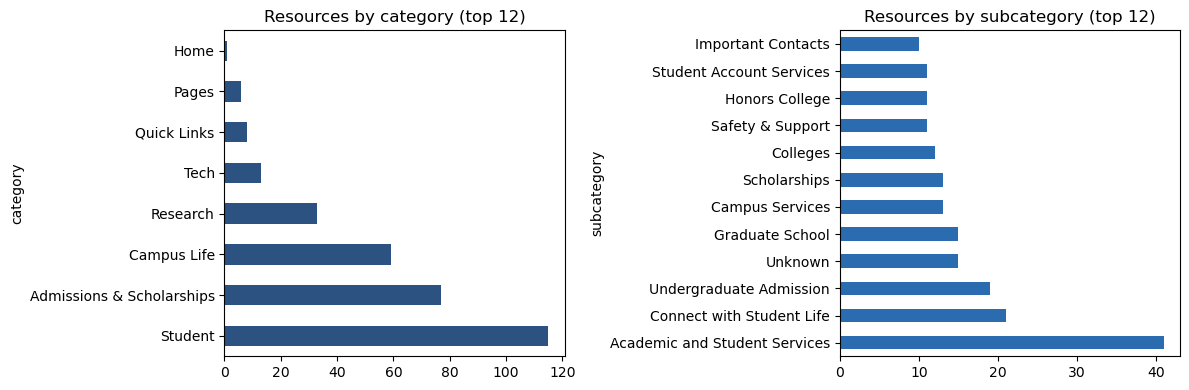

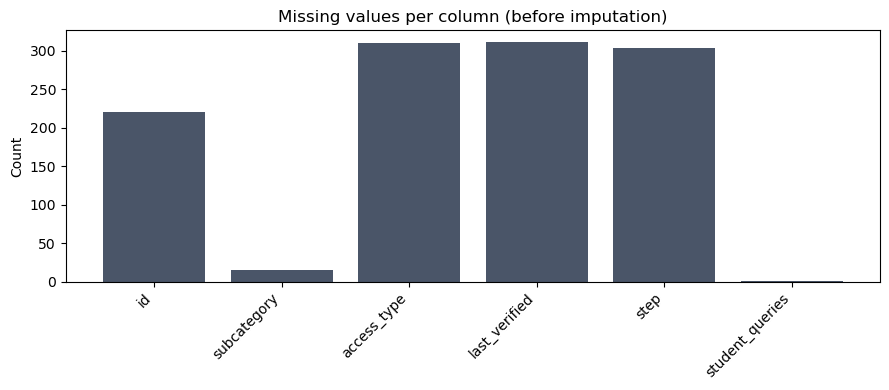

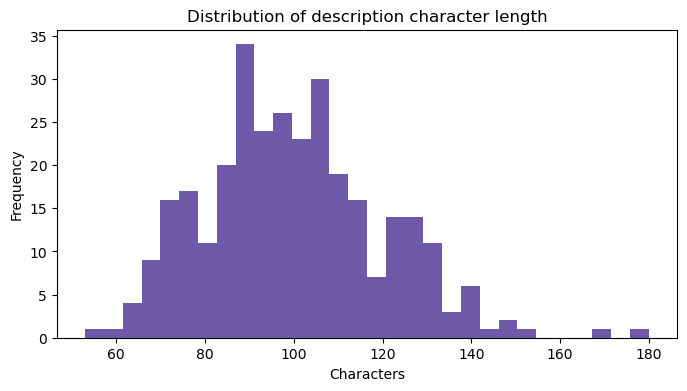

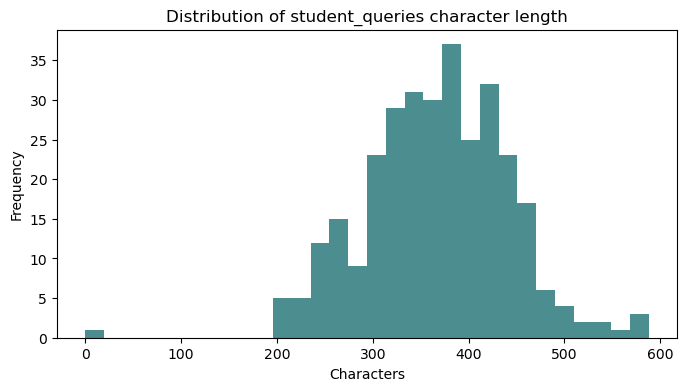

In [2]:
# --- Load primary catalog (enriched spreadsheet) ---
DATA_FILE = "ua_resources_filled.xlsx"
if not Path(DATA_FILE).exists():
    DATA_FILE = "ua_resources.xlsx"

df = pd.read_excel(DATA_FILE)
print(f"Loaded: {DATA_FILE}")
print("Shape (rows, columns):", df.shape)
display(df.head(3))
print("\nColumn dtypes:")
print(df.dtypes)

# --- Duplicate resources (same display name) ---
df["resource_name"] = df["resource_name"].astype(str).str.strip()
rows_before = len(df)
dup_mask = df["resource_name"].str.lower().duplicated(keep=False)
print(f"\nRows with duplicate resource_name (case-insensitive): {dup_mask.sum()}")
name_counts = df["resource_name"].str.lower().value_counts()
print("Top duplicated names:")
display(name_counts[name_counts > 1].head(10).to_frame("count"))

df = df.drop_duplicates(subset=["resource_name"], keep="first").reset_index(drop=True)
rows_after = len(df)
print(f"\nRows before → after deduplication: {rows_before} → {rows_after}")

# --- EDA visualizations (Stage 1) ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["category"].fillna("").value_counts().head(12).plot(kind="barh", ax=axes[0], color="#2c5282")
axes[0].set_title("Resources by category (top 12)")
df["subcategory"].fillna("Unknown").value_counts().head(12).plot(kind="barh", ax=axes[1], color="#2b6cb0")
axes[1].set_title("Resources by subcategory (top 12)")
plt.tight_layout()
plt.show()

miss = df.isnull().sum()
miss = miss[miss > 0]
plt.figure(figsize=(9, 4))
plt.bar(miss.index.astype(str), miss.values, color="#4a5568")
plt.title("Missing values per column (before imputation)")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Description length from raw `description` (Stage 1 EDA; `search_text` length is plotted after feature engineering)
dl = df["description"].fillna("").str.len()
plt.figure(figsize=(8, 4))
plt.hist(dl, bins=30, color="#553c9a", alpha=0.85)
plt.title("Distribution of description character length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()

sq = df["student_queries"].fillna("").astype(str).str.len()
plt.figure(figsize=(8, 4))
plt.hist(sq, bins=30, color="#2c7a7b", alpha=0.85)
plt.title("Distribution of student_queries character length")
plt.xlabel("Characters")
plt.ylabel("Frequency")
plt.show()


**EDA interpretation:** Category/subcategory plots show how services are spread across campus; imbalance is expected (academic vs. administrative). The missing-value chart guides which text fields need imputation. Description length shows whether resources have enough text for retrieval.


### Duplicate handling

Rows sharing the same `resource_name` (after stripping) were treated as duplicates of one catalog entry. We **keep the first row** and drop later rows so each resource name appears once. This matches the deployment goal: one row per service in the search index.


### Handling Missing Values

Missing values were identified across several columns, particularly in fields that are generated during later preprocessing stages such as keywords and student queries.

In [3]:
# Missing counts immediately after deduplication (before filling)
print("Missing values BEFORE imputation:")
print(df.isnull().sum())


Missing values BEFORE imputation:
id                 220
resource_name        0
category             0
subcategory         15
description          0
target_users         0
keywords             0
url                  0
access_type        310
last_verified      311
step               303
student_queries      1
search_text          0
dtype: int64


In [4]:
# --- Impute missing text fields (retrieval surface) ---
df["subcategory"] = df["subcategory"].fillna("Unknown")
for col in ["description", "keywords", "student_queries", "category"]:
    df[col] = df[col].fillna("")
# target_users: fill for modeling; many rows may remain empty if absent in source
df["target_users"] = df["target_users"].fillna("")

print("Missing values AFTER text imputation:")
print(df.isnull().sum())


Missing values AFTER text imputation:
id                 220
resource_name        0
category             0
subcategory          0
description          0
target_users         0
keywords             0
url                  0
access_type        310
last_verified      311
step               303
student_queries      0
search_text          0
dtype: int64


**Cleaning decisions:** Categorical `subcategory` uses `"Unknown"` so plots and grouping stay well-defined. Free-text fields use `""` instead of null to avoid errors in string concatenation. Metadata columns with sparse survey-style fields (`access_type`, `last_verified`, `step`) are left as-is when missing; they are **not** mixed into `search_text` because they do not help student phrasing and are often empty.


### Data Cleaning and Normalization

Text inconsistencies such as extra whitespace and inconsistent capitalization were corrected to ensure uniform representation of resources.

In [5]:
df["resource_name"] = df["resource_name"].str.strip()
df["subcategory"] = df["subcategory"].astype(str).str.strip()
df["resource_name"] = df["resource_name"].str.title()


### Feature Engineering: search_text

To improve retrieval performance, multiple text-based fields were combined into a single feature called `search_text`. This feature aggregates resource names, descriptions, keywords, and user-oriented query phrases into one unified representation.

Certain fields were weighted more heavily to reflect their importance in search. Specifically, resource names and student queries were emphasized to improve matching accuracy.

In [6]:
df["search_text"] = (
    (df["resource_name"] + " ") * 3
    + (df["student_queries"] + " ") * 2
    + df["description"] + " "
    + df["keywords"] + " "
    + df["category"] + " "
    + df["subcategory"]
).str.lower()

# Additional engineered features (for analysis / transparency)
df["search_length"] = df["search_text"].str.len()
df["keyword_token_count"] = df["keywords"].apply(
    lambda s: len([t for t in re.split(r"[\s,]+", str(s).strip()) if t])
)
df["category_subcat_key"] = (
    df["category"].str.strip().str.lower()
    + " | "
    + df["subcategory"].str.strip().str.lower()
)

display(df[["resource_name", "search_length", "keyword_token_count", "category_subcat_key"]].head(3))


,resource_name,search_length,keyword_token_count,category_subcat_key
0,Academic Calendar,932,11,quick links | unknown
1,Blackboard,645,12,quick links | unknown
2,Degree Works,199,6,quick links | unknown


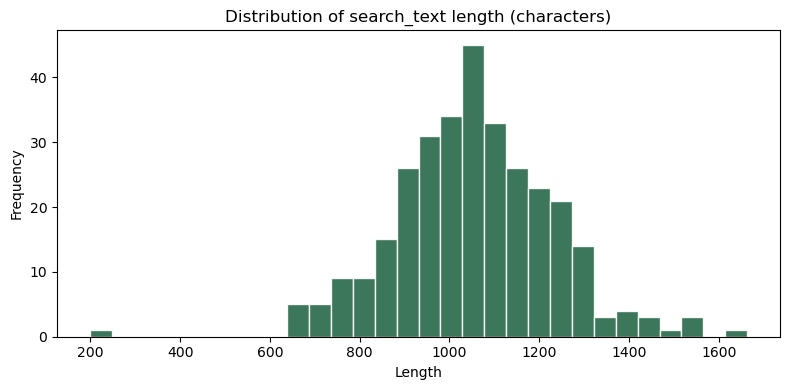

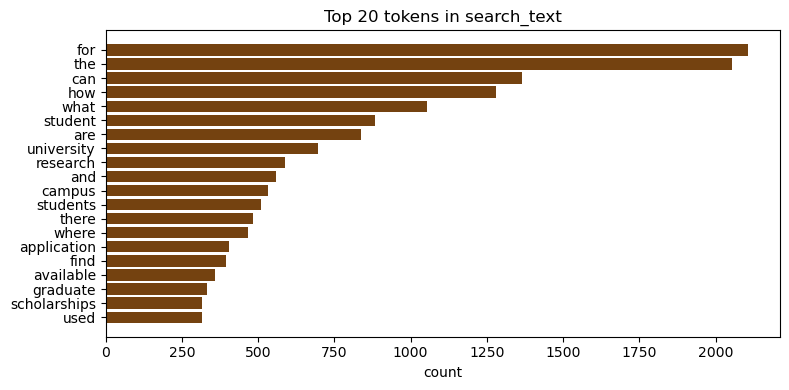

In [7]:
plt.figure(figsize=(8, 4))
plt.hist(df["search_length"], bins=30, color="#276749", edgecolor="white", alpha=0.9)
plt.title("Distribution of search_text length (characters)")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# Frequent tokens in search_text (lightweight)
tokens = []
for t in df["search_text"].dropna().astype(str):
    tokens += re.findall(r"[a-zA-Z]{3,}", t.lower())
top = Counter(tokens).most_common(20)
plt.figure(figsize=(8, 4))
plt.barh([w for w, _ in reversed(top)], [c for _, c in reversed(top)], color="#744210")
plt.title("Top 20 tokens in search_text")
plt.xlabel("count")
plt.tight_layout()
plt.show()


### Data quality and feature selection

**`search_text`** is the unified retrieval field: name and student-style queries are up-weighted, then description, keywords, and taxonomy terms. **Auxiliary features** (`search_length`, `keyword_token_count`, `category_subcat_key`) summarize coverage and structure; the deployed API uses dense embeddings over `search_text`, consistent with this notebook.

**Before/after:** Row counts from deduplication are printed above; missing-value counts are shown before and after imputation.


**Production note:** Retrieval here is a full linear scan over embeddings (cosine similarity). For much larger catalogs, an approximate nearest-neighbor index (FAISS, Annoy, or a managed vector database) would reduce latency; the modeling conclusions in this notebook still apply.


## Stage 3: Modeling & evaluation

### Approaches compared
1. **TF-IDF + cosine similarity** — sparse baseline, fast, interpretable token overlap.
2. **Sentence-BERT (`all-MiniLM-L6-v2`) + cosine similarity** — dense semantic similarity.
3. **Same embeddings + rule-based query expansion** — adds domain phrases for common student intents (mirrors `semantic_search.py`).

### Train/validation/test split
We use a random **row split** (80/10/10) only to mirror experimentation workflow. **Retrieval evaluation** indexes the **full** cleaned catalog (deployment-realistic): every resource is a candidate document. Metrics are computed on a fixed **query set** with labeled relevant `resource_name` values (normalized to lower case).

### Metrics
**Precision@5**, **Recall@5** (hits divided by $\min(|\text{relevant}|, 5)$), and **MRR** (reciprocal rank of first relevant hit). These are standard for ranked retrieval when there is no single “correct class” per query.

### Hyperparameter tuning (TF-IDF)

TF-IDF settings are chosen by **grid search** over `max_features`, `ngram_range`, and `min_df`, maximizing **mean reciprocal rank (MRR)** on the labeled query set above. This ties tuning directly to retrieval quality rather than to auxiliary similarity statistics.


In [8]:
# --- Full-corpus retrieval index (all resources) ---
corpus_df = df.reset_index(drop=True)

def norm_name(x):
    return str(x).strip().lower()

def norm_rel(names):
    return [norm_name(n) for n in names]

# Reference split sizes (optional reporting)
train_df, temp_df = train_test_split(corpus_df, test_size=0.2, random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)
print(f"Row split sizes — train: {len(train_df)}, val: {len(val_df)}, test: {len(test_df)}")
print("Evaluation uses the full corpus as the document index (see Stage 3 markdown).")

corpus_text = corpus_df["search_text"].tolist()

# --- TF-IDF: grid search maximizing mean MRR on the query set ---
test_queries = [
    ("build my schedule", ["schedule builder"]),
    ("view my schedule", ["student detail schedule"]),
    ("mental health help", ["counseling center", "student care and well-being"]),
    ("study abroad funding", ["education abroad grant"]),
    ("find a job", ["part-time job board"]),
    ("meal plan", ["order a meal plan"]),
]

def precision_at_k(results, relevant, k=5):
    rel = set(norm_rel(relevant))
    results = [norm_name(r) for r in results[:k]]
    hits = sum(1 for r in results if r in rel)
    return hits / k


def recall_at_k(results, relevant, k=5):
    relevant = norm_rel(relevant)
    results = [norm_name(r) for r in results[:k]]
    rel = set(relevant)
    hits = sum(1 for r in results if r in rel)
    denom = min(len(rel), k)
    return hits / denom if denom else 0.0


def mrr_score(results, relevant):
    relevant = set(norm_rel(relevant))
    for i, r in enumerate([norm_name(x) for x in results]):
        if r in relevant:
            return 1.0 / (i + 1)
    return 0.0


def tfidf_search_matrix(query, matrix, vec, top_k=5):
    qv = vec.transform([query])
    scores = cosine_similarity(qv, matrix)[0]
    idx = scores.argsort()[-top_k:][::-1]
    return [norm_name(corpus_df.iloc[i]["resource_name"]) for i in idx]


def mean_mrr_for_tfidf(vec):
    X = vec.fit_transform(corpus_text)
    total = 0.0
    for q, rel in test_queries:
        total += mrr_score(tfidf_search_matrix(q, X, vec), rel)
    return total / len(test_queries)


param_grid = {
    "max_features": [3000, 5000],
    "ngram_range": [(1, 1), (1, 2)],
    "min_df": [1, 2],
}

best_mrr = -1.0
best_params = None
for params in ParameterGrid(param_grid):
    vec = TfidfVectorizer(**params)
    score = mean_mrr_for_tfidf(vec)
    if score > best_mrr:
        best_mrr = score
        best_params = params

print("Best TF-IDF params (by mean MRR on query set):", best_params, "MRR:", round(best_mrr, 4))

vectorizer = TfidfVectorizer(**best_params)
corpus_tfidf = vectorizer.fit_transform(corpus_text)

# --- Sentence embeddings over full corpus ---
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2", device="cpu")
corpus_emb = model.encode(corpus_text, show_progress_bar=True, batch_size=64)


def embed_search_raw(query, top_k=5):
    qv = model.encode([query])
    scores = cosine_similarity(qv, corpus_emb)[0]
    idx = scores.argsort()[-top_k:][::-1]
    return [norm_name(corpus_df.iloc[i]["resource_name"]) for i in idx]


def expand_query(q: str) -> str:
    q = q.lower()
    extra = []
    if "grade" in q:
        extra.append("check grades blackboard assignments")
    if "class" in q or "course" in q:
        extra.append("schedule classes degreeworks")
    if "email" in q or "contact" in q:
        extra.append("email professor faculty directory")
    if "scholarship" in q:
        extra.append("apply scholarships financial aid")
    return q + " " + " ".join(extra)


def embed_search_expanded(query, top_k=5):
    return embed_search_raw(expand_query(query), top_k=top_k)


def eval_model(name, search_fn):
    rows = []
    for q, rel in test_queries:
        res = search_fn(q)
        rows.append({
            "query": q,
            "precision@5": precision_at_k(res, rel),
            "recall@5": recall_at_k(res, rel),
            "mrr": mrr_score(res, rel),
        })
    return pd.DataFrame(rows)


def summarize(df_metrics):
    return {
        "precision@5": df_metrics["precision@5"].mean(),
        "recall@5": df_metrics["recall@5"].mean(),
        "mrr": df_metrics["mrr"].mean(),
    }


tfidf_metrics = eval_model("tfidf", lambda q: tfidf_search_matrix(q, corpus_tfidf, vectorizer))
emb_metrics = eval_model("embed", embed_search_raw)
emb_x_metrics = eval_model("embed+expand", embed_search_expanded)

sum_tfidf = summarize(tfidf_metrics)
sum_emb = summarize(emb_metrics)
sum_ex = summarize(emb_x_metrics)

comparison = pd.DataFrame([
    {"Model": "TF-IDF + cosine", **sum_tfidf},
    {"Model": "MiniLM embeddings", **sum_emb},
    {"Model": "MiniLM + query expansion", **sum_ex},
])
print(comparison.round(4))

# Qualitative examples
demo_q = "how do i check my grades"
print("\nQualitative — query:", repr(demo_q))
print("TF-IDF top-5:", tfidf_search_matrix(demo_q, corpus_tfidf, vectorizer))
print("Embeddings top-5:", embed_search_raw(demo_q))
print("Embeddings + expansion top-5:", embed_search_expanded(demo_q))


Row split sizes — train: 249, val: 31, test: 32
Evaluation uses the full corpus as the document index (see Stage 3 markdown).


Best TF-IDF params (by mean MRR on query set): {'max_features': 3000, 'min_df': 1, 'ngram_range': (1, 1)} MRR: 0.5472


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/5 [00:00<?, ?it/s]

                      Model  precision@5  recall@5     mrr
0           TF-IDF + cosine       0.2000    0.9167  0.5472
1         MiniLM embeddings       0.2333    1.0000  0.5278
2  MiniLM + query expansion       0.2333    1.0000  0.5278

Qualitative — query: 'how do i check my grades'
TF-IDF top-5: ['view grades', 'view student information', 'unofficial transcript', 'blackboard', 'check my application status']
Embeddings top-5: ['view grades', 'view student information', 'unofficial transcript', 'academic profile', 'registration status']
Embeddings + expansion top-5: ['blackboard', 'view grades', 'view student information', 'unofficial transcript', 'registration status']


In [9]:
# Per-query breakdown (embeddings model)
display(emb_metrics)


,query,precision@5,recall@5,mrr
0,build my schedule,0.2,1.0,0.500000
1,view my schedule,0.2,1.0,0.500000
2,mental health help,0.4,1.0,0.500000
3,study abroad funding,0.2,1.0,0.333333
4,find a job,0.2,1.0,0.333333
5,meal plan,0.2,1.0,1.000000


In [10]:
results_df = comparison.copy()
print(results_df.round(4))


                      Model  precision@5  recall@5     mrr
0           TF-IDF + cosine       0.2000    0.9167  0.5472
1         MiniLM embeddings       0.2333    1.0000  0.5278
2  MiniLM + query expansion       0.2333    1.0000  0.5278


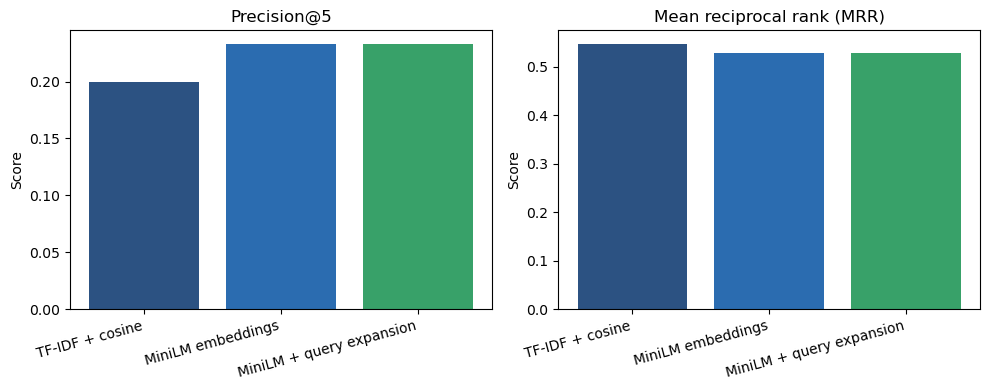

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
models = results_df["Model"].tolist()
x = np.arange(len(models))
axes[0].bar(x, results_df["precision@5"], color=["#2c5282", "#2b6cb0", "#38a169"])
axes[0].set_xticks(x)
axes[0].set_xticklabels(models, rotation=15, ha="right")
axes[0].set_title("Precision@5")
axes[0].set_ylabel("Score")

axes[1].bar(x, results_df["mrr"], color=["#2c5282", "#2b6cb0", "#38a169"])
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=15, ha="right")
axes[1].set_title("Mean reciprocal rank (MRR)")
axes[1].set_ylabel("Score")
plt.tight_layout()
plt.show()


### Model comparison and deployment choice

| Model | Strengths | Weaknesses |
|-------|-----------|------------|
| TF-IDF | Fast, no GPU, interpretable tokens | Misses paraphrases; brittle when wording differs |
| Dense embeddings | Captures semantics and student phrasing | Heavier compute; depends on model quality |
| + Query expansion | Cheap recall boost on domain phrases | Heuristic rules need maintenance |

**Choice aligned with the repo:** The FastAPI service uses **SentenceTransformer embeddings + cosine similarity** over the full catalog (`app.py`). TF-IDF remains a transparent baseline for this report.
